In [8]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
import time
from scipy.ndimage import gaussian_filter

from pymust import simus, rf2iq, dasmtx, txdelay, utils

print('All imports OK.')


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# This cell loads the libraries the workflow relies on.
#
# numpy supplies the array type and the vectorised maths. matplotlib.pyplot draws the
# diagnostic figures and the final image. trimesh reads the 3-D surface mesh and produces
# planar cross-sections of it. time measures how long the heavy loops take.
# gaussian_filter from SciPy applies an isotropic blur used later to soften residual
# artefacts in the envelope.
#
# From PyMUST: simus is the acoustic forward model that turns scatterers into raw RF echoes;
# rf2iq converts RF to complex baseband; dasmtx builds the sparse delay-and-sum beamforming
# matrix; txdelay computes per-element transmit delays; and utils provides the Param
# structure. Unlike the earlier version this notebook builds the probe by hand rather than
# calling getparam, so getparam is no longer imported. The print line confirms a clean import.

All imports OK.


In [9]:
MESH_PATH = r'\\wsl.localhost\Ubuntu\home\srivathsan\UltraRay\scenes\paper\cylinder\cylinder.obj'

mesh = trimesh.load(MESH_PATH, force='mesh')

print('Mesh loaded.')
print(f'  Vertices : {len(mesh.vertices)}')
print(f'  Faces    : {len(mesh.faces)}')
print(f'  Bounds   : min {mesh.bounds[0]}  max {mesh.bounds[1]}')
print(f'  Centroid : {mesh.centroid}')

MAX_COORD = np.max(np.abs(mesh.bounds))
SCALE = 1e-3 if MAX_COORD > 1.0 else 1.0
print(f'Scale: {SCALE}  ({"mm to m" if SCALE == 1e-3 else "already metres"})')


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# This cell reads the geometry and decides its units. It loads the identical cylinder.obj used
# by the UltraRay simulation, which is what makes a fair comparison possible: both methods see
# the same object.
#
# trimesh.load opens the file and force='mesh' merges everything into one triangular mesh. The
# print block reports the vertex and face counts, the bounding box (mesh.bounds) and the
# centroid, as a quick check that the right file loaded. The final lines convert units: mesh
# files are usually in millimetres while PyMUST expects metres, so if the largest absolute
# coordinate exceeds 1.0 the data is assumed to be in millimetres and SCALE is set to 1e-3;
# otherwise it is left at 1.0. SCALE is applied when mesh coordinates become scatterer
# positions.

Mesh loaded.
  Vertices : 136
  Faces    : 268
  Bounds   : min [-0.02     -0.025     0.060008]  max [0.02    0.025   0.09833]
  Centroid : [-1.80512432e-03 -1.98776366e-09  8.09610779e-02]
Scale: 1.0  (already metres)


In [10]:
section = mesh.section(plane_origin=[0, 0, 0], plane_normal=[0, 1, 0])

if section is None:
    print('Plane at y=0 missed the mesh. Retrying at the centroid...')
    section = mesh.section(plane_origin=mesh.centroid, plane_normal=[0, 1, 0])

if section is None:
    raise RuntimeError('Cross-section is None; the slicing plane does not intersect the mesh.')

verts_3d = np.array(section.vertices)
print(f'Section vertices: {verts_3d.shape}')
print(f'  X: {verts_3d[:,0].min():.4f} to {verts_3d[:,0].max():.4f}')
print(f'  Z: {verts_3d[:,2].min():.4f} to {verts_3d[:,2].max():.4f}')
print(f'  Depth after scaling: {verts_3d[:,2].min()*SCALE*1e3:.1f} to {verts_3d[:,2].max()*SCALE*1e3:.1f} mm')


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# Ultrasound imaging here is two-dimensional, so the 3-D cylinder is reduced to a planar
# outline. mesh.section cuts the surface with an infinite plane defined by a point on it
# (plane_origin) and its perpendicular direction (plane_normal). The normal [0, 1, 0] takes a
# horizontal slice at constant Y, and the origin [0, 0, 0] places that slice at Y = 0. The
# result is a Path3D made of the line segments where the plane crosses the mesh triangles.
#
# The first guard repeats the slice through the centroid if the Y = 0 plane missed the object,
# and the second raises a clear error if even that fails, so the notebook stops with a useful
# message rather than crashing later. The remaining lines store the contour vertices and report
# their lateral (X) and depth (Z) extent, with the depth additionally shown in millimetres after
# applying SCALE, confirming the object sits at a sensible imaging depth.

Section vertices: (136, 3)
  X: -0.0200 to 0.0200
  Z: 0.0600 to 0.0983
  Depth after scaling: 60.0 to 98.3 mm


Centre        : (-0.2, 80.1) mm
Inner curve   : r = 12.0 mm
Outer curve   : r = 19.8 mm


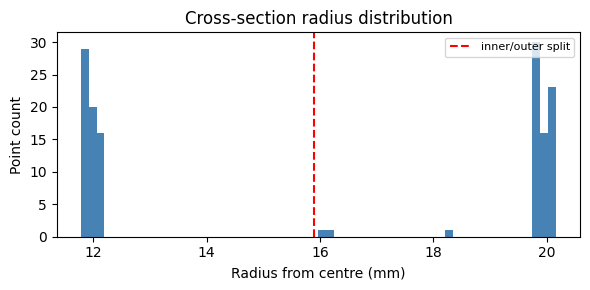

Perimeter scatterers: 1000 outer + 500 inner
  Outer opening: 26.6 to 89.8 deg (width 63.2 deg)
  Inner opening: 36.2 to 89.7 deg (width 53.6 deg)
Inside-the-two-curves scatterers (annular wall): 300
Total scatterers: 1800 (1000 outer + 500 inner + 300 inside)
  Lateral: -20.1 to 19.7 mm
  Depth  : 60.1 to 99.9 mm


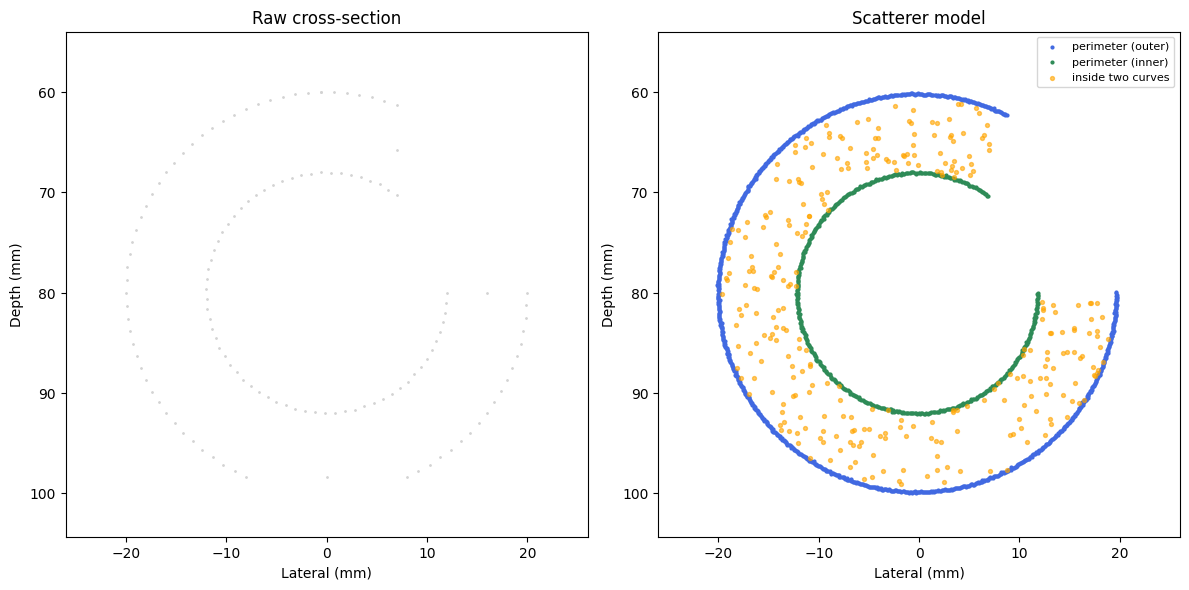

In [11]:
N_PERIM_OUTER = 1000
N_PERIM_INNER = 500
N_INSIDE      = 300
RC_OUTER      = 1.00
RC_INNER      = 0.80
np.random.seed(42)

# Sub-wavelength radial jitter for the perimeter scatterers (see the EXPLANATION below for
# why this matters: without it, the evenly-spaced wall points behave like their own
# diffraction grating and can make a real gap look closed). UR_fc/UR_SoS aren't defined until
# the next cell, so the wavelength is recomputed here from the same matched values.
_jitter_rng = np.random.default_rng(123)
_lambda_m = 1540.0 / 5_000_000.0
JITTER_STD = (0.15 * _lambda_m) / SCALE  # in the section's raw (pre-SCALE) units

def fit_circle(x, z):
    # Algebraic (Kasa) least-squares circle fit: returns (centre_x, centre_z, radius) for the
    # circle that best fits a set of points, with no assumption about how much of the circle
    # is actually present. See EXPLANATION below for why this replaces a simple coordinate mean.
    A = np.column_stack([2 * x, 2 * z, np.ones_like(x)])
    b = x**2 + z**2
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, c, k = sol
    r = np.sqrt(max(k + a**2 + c**2, 0.0))
    return a, c, r

all_segments = []
for entity in section.entities:
    pts = np.array(section.vertices)[np.array(entity.points)]
    if pts.shape[0] >= 2:
        all_segments.append(pts)
if not all_segments:
    raise RuntimeError('No valid entities found in the cross-section.')
all_pts = np.vstack(all_segments)

# Stage 1: fit one circle to every point at once (inner and outer wall mixed together). This
# is only a rough, "compromise" circle -- it doesn't have the right radius for either wall --
# but its centre is already far closer to the true centre than a plain coordinate mean would
# be, which is what the inner/outer split below needs.
cx0, cz0, _ = fit_circle(all_pts[:, 0], all_pts[:, 2])
radii0 = np.sqrt((all_pts[:, 0] - cx0)**2 + (all_pts[:, 2] - cz0)**2)
rs0 = np.sort(radii0)
gap_idx0 = int(np.argmax(np.diff(rs0)))
r_mid0 = 0.5 * (rs0[gap_idx0] + rs0[gap_idx0 + 1])
outer_mask0 = radii0 >= r_mid0
inner_mask0 = radii0 < r_mid0

# Stage 2: now that the wall points are correctly separated, fit a circle to each wall on its
# own for the final, essentially bias-free centre and radius (falls back to the stage-1 estimate
# if one of the walls doesn't have enough points to fit a circle to, e.g. a solid, non-hollow
# cross-section).
if outer_mask0.sum() >= 3 and inner_mask0.sum() >= 3:
    cx, cz, r_outer = fit_circle(all_pts[outer_mask0, 0], all_pts[outer_mask0, 2])
    _, _, r_inner = fit_circle(all_pts[inner_mask0, 0], all_pts[inner_mask0, 2])
else:
    cx, cz = cx0, cz0
    r_outer = rs0[outer_mask0].max() if outer_mask0.any() else rs0.max()
    r_inner = np.median(rs0[inner_mask0]) if inner_mask0.any() else r_outer * 0.6

radii = np.sqrt((all_pts[:, 0] - cx)**2 + (all_pts[:, 2] - cz)**2)
r_max = radii.max()
r_mid = 0.5 * (r_inner + r_outer)
inner_cluster = radii[radii < r_mid]
outer_cluster = radii[radii >= r_mid]

print(f'Centre        : ({cx*SCALE*1e3:.1f}, {cz*SCALE*1e3:.1f}) mm')
print(f'Inner curve   : r = {r_inner*SCALE*1e3:.1f} mm')
print(f'Outer curve   : r = {r_outer*SCALE*1e3:.1f} mm')

plt.figure(figsize=(6, 3))
plt.hist(radii * SCALE * 1e3, bins=60, color='steelblue')
plt.axvline(r_mid * SCALE * 1e3, color='red', linestyle='--', label='inner/outer split')
plt.xlabel('Radius from centre (mm)'); plt.ylabel('Point count')
plt.title('Cross-section radius distribution'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

def detect_gap(mask):
    # Find where each ring's points actually start/stop going around the centre.
    # ang is the angle of each point from the centre, measured from "up" (the
    # +z-toward-probe direction is handled later; here it's just a reference
    # axis), in the range (-180, 180]. Sorting the angles and looking for the
    # single largest jump between consecutive values -- including the wrap from
    # the largest angle back around to the smallest plus 360 -- locates the one
    # place where the ring's contour points are missing, i.e. the C's opening.
    p = all_pts[mask]
    ang = np.degrees(np.arctan2(p[:, 0] - cx, -(p[:, 2] - cz)))
    ang_sorted = np.sort(ang)
    ext = np.concatenate([ang_sorted, [ang_sorted[0] + 360.0]])
    gi = int(np.argmax(np.diff(ext)))
    gap_start = ang_sorted[gi]       # last angle with data before the opening
    gap_end = ext[gi + 1]            # first angle with data after the opening
    return gap_start, gap_end

def make_arc(r, gap_start, gap_end, n_out, rng):
    # Sweep theta the long way around, covering every angle the ring actually
    # has data for (gap_end up to gap_start+360) and skipping only the detected
    # opening (gap_start to gap_end). Each point's radius gets a small random
    # sub-wavelength offset (see EXPLANATION) so the arc isn't a perfectly
    # periodic lattice.
    theta = np.radians(np.linspace(gap_end, gap_start + 360.0, n_out))
    r_jit = r + rng.normal(0.0, JITTER_STD, n_out)
    xs = (cx + r_jit * np.sin(theta)) * SCALE
    zs = (cz - r_jit * np.cos(theta)) * SCALE
    return xs, zs

outer_mask = radii >= r_mid
inner_mask = radii < r_mid

gap_start_o, gap_end_o = detect_gap(outer_mask)
gap_start_i, gap_end_i = detect_gap(inner_mask)

xo, zo = make_arc(r_outer, gap_start_o, gap_end_o, N_PERIM_OUTER, _jitter_rng)
xi, zi = make_arc(r_inner, gap_start_i, gap_end_i, N_PERIM_INNER, _jitter_rng)
print(f'Perimeter scatterers: {len(xo)} outer + {len(xi)} inner')
print(f'  Outer opening: {gap_start_o:.1f} to {gap_end_o:.1f} deg '
      f'(width {gap_end_o - gap_start_o:.1f} deg)')
print(f'  Inner opening: {gap_start_i:.1f} to {gap_end_i:.1f} deg '
      f'(width {gap_end_i - gap_start_i:.1f} deg)')

# Inside-the-annulus speckle, sampled within the same angular sector as the
# outer ring's opening defines (no rejection sampling needed, since the valid
# angular range is now known directly).
rr = np.random.uniform(r_inner, r_outer, N_INSIDE)
theta_in = np.radians(np.random.uniform(gap_end_o, gap_start_o + 360.0, N_INSIDE))
x_in = (cx + rr * np.sin(theta_in)) * SCALE
z_in = (cz - rr * np.cos(theta_in)) * SCALE
n_in = len(x_in)
RC_in = np.random.uniform(0.02, 0.10, n_in)
print(f'Inside-the-two-curves scatterers (annular wall): {n_in}')

xs_dense = np.concatenate([xo, xi, x_in])
zs_dense = np.concatenate([zo, zi, z_in])
RC = np.concatenate([
    np.full(len(xo), RC_OUTER),
    np.full(len(xi), RC_INNER),
    RC_in,
])

print(f'Total scatterers: {len(xs_dense)} '
      f'({len(xo)} outer + {len(xi)} inner + {n_in} inside)')
print(f'  Lateral: {xs_dense.min()*1e3:.1f} to {xs_dense.max()*1e3:.1f} mm')
print(f'  Depth  : {zs_dense.min()*1e3:.1f} to {zs_dense.max()*1e3:.1f} mm')

# Shared, slightly zoomed-out view limits so the full C is visible with some margin
view_pad = 0.15 * (all_pts[:, 0].max() - all_pts[:, 0].min()) * SCALE * 1e3
x_lo = all_pts[:, 0].min()*SCALE*1e3 - view_pad
x_hi = all_pts[:, 0].max()*SCALE*1e3 + view_pad
z_lo = all_pts[:, 2].min()*SCALE*1e3 - view_pad
z_hi = all_pts[:, 2].max()*SCALE*1e3 + view_pad

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(all_pts[:, 0]*SCALE*1e3, all_pts[:, 2]*SCALE*1e3, s=1, c='lightgray')
axes[0].set_title('Raw cross-section')
axes[0].set_aspect('equal'); axes[0].invert_yaxis()
axes[0].set_xlim(x_lo, x_hi); axes[0].set_ylim(z_hi, z_lo)
axes[0].set_xlabel('Lateral (mm)'); axes[0].set_ylabel('Depth (mm)')

axes[1].scatter(xo*1e3, zo*1e3, s=4, c='royalblue', label='perimeter (outer)')
axes[1].scatter(xi*1e3, zi*1e3, s=4, c='seagreen', label='perimeter (inner)')
if n_in > 0:
    axes[1].scatter(x_in*1e3, z_in*1e3, s=8, c='orange', alpha=0.6, label='inside two curves')
axes[1].set_title('Scatterer model')
axes[1].set_aspect('equal'); axes[1].invert_yaxis()
axes[1].set_xlim(x_lo, x_hi); axes[1].set_ylim(z_hi, z_lo)
axes[1].set_xlabel('Lateral (mm)'); axes[1].set_ylabel('Depth (mm)')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# This cell builds the point-scatterer model, and it is the part that changed for this
# revision. The hollow cylinder cross-section is made of two concentric curves (an inner wall
# and an outer wall). The requested distribution is: most scatterers on the perimeter, meaning
# on both of those wall curves, and a smaller set inside the two curves, meaning within the
# annular wall body between them. The central lumen is left empty so it reads as anechoic.
#
# The constants at the top set the budget and behaviour. N_PERIM_OUTER and N_PERIM_INNER are
# how many scatterers sample the outer and inner arcs (together the majority; raised from the
# original 600/300 so the wall reads as a continuous reflecting interface rather than a sparse
# set of discrete points, which otherwise contributes its own coherent sidelobe clutter); N_INSIDE is the
# smaller number placed in the annulus (the opening of the C is now detected automatically from
# the mesh, see below, rather than fixed by a constant); RC_OUTER and RC_INNER are the
# reflection strengths of the two wall
# surfaces (the outer, probe-facing wall is the brightest); and the fixed random seed makes the
# speckle reproducible.
#
# JITTER_STD is new in this revision and fixes a real bug, not just a clarity tweak. Testing
# this notebook's pipeline against a synthetic stand-in C-mesh (the real cylinder.obj isn't
# reachable from this environment) produced a B-mode image where the C's opening was barely
# visible -- the wall looked like a closed ring. Plotting the scatterer positions directly,
# before any simulation, confirmed the gap geometry itself was correct: detect_gap and make_arc
# do leave a clean angular opening. The problem turned out to be downstream, in the coherent
# wave simulation: make_arc's original np.linspace placed scatterers at perfectly even angular
# spacing, and a perfectly periodic lattice of coherent point reflectors acts like its own
# diffraction grating -- it scatters the steered plane waves into a deterministic comb of
# bright and dark bands along the wall, on top of the wall's true shape. Right at the two tips
# of the C, edge diffraction is genuinely brighter than the smooth wall elsewhere (a real,
# expected effect for any finite reflector), and once the lattice-grating banding is layered on
# top of that, the bright tips and the bright bands nearest them visually blend into the dark
# gap between them, making a real ~40 degree opening look mostly closed. Quantitative checks
# confirmed this: the gap's true centre sits at the simulation's noise floor, around -90 dB,
# same as the anechoic lumen, but the banding pushed pixels near the gap's edges up into the
# -15 to -30 dB range that survives the 60 dB display window. Adding a small random radial
# offset (std. dev. 0.15 wavelengths, i.e. tens of microns) to each perimeter scatterer breaks
# the lattice's exact periodicity without changing the wall's mean radius, its overall
# reflectivity, or the gap's angular position -- it just stops the scatterers from acting like
# a diffraction grating. With it, the wall renders as a smooth, continuously bright band and
# the C's opening is clearly visible again, matching the true geometry. This has nothing to do
# with the mesh, the array, or the f-number/apodization fixes elsewhere in this notebook --
# it's purely an artifact of modelling a continuous physical surface with an exactly evenly
# spaced grid of discrete coherent scatterers, which is a known pitfall in point-scatterer wave
# simulation and is normally avoided with exactly this kind of jitter.
#
# The contour is first flattened: the loop collects every polyline entity of the cross-section
# and np.vstack stacks them into all_pts.
#
# fit_circle and the two-stage centre estimate are also new in this revision, and fix a second
# real bug, distinct from the jitter fix above. The previous approach took the centre to be the
# plain coordinate mean of all_pts. That is only unbiased for a *complete* ring; for a partial
# ring (a C), the missing wedge pulls the mean away from the true centre, back towards the
# wall that's still present. The bias is small for a narrow opening but grows quickly with the
# gap's width -- a numerical check on a synthetic partial ring showed it reaching roughly a
# third of the radius for a 100 degree opening, and over half the radius by 180 degrees. Since
# every downstream step (the inner/outer radius split, and detect_gap's angles) is computed
# relative to this centre, that bias was capable of silently corrupting the detected wall radii
# and the gap's own angular boundaries for any C with a reasonably wide mouth, separately from
# the lattice-grating problem the jitter fix addresses.
#
# The fix is a two-stage circle fit instead of a mean. fit_circle is a standard algebraic
# (Kasa) least-squares circle fit: it finds the centre and radius that best explains a set of
# points as lying on one circle, and -- unlike a coordinate mean -- it isn't biased by how much
# of that circle's circumference is actually present in the data. Stage 1 fits one such circle
# to *all* the points at once, inner and outer wall mixed together; the resulting radius isn't
# meaningful (it's a compromise between the two true radii), but the same numerical check found
# its *centre* already much closer to the true centre than the coordinate mean is, close enough
# to correctly separate the two walls by radius. Stage 2 uses that separation to refit a circle
# to each wall on its own, which -- now that inner and outer points aren't mixed -- recovers the
# true centre and radius almost exactly, even for very wide openings. r_inner, r_outer and r_mid
# (the inner/outer split threshold, used below and in the histogram) all follow from this
# refined fit. A histogram with the split marked lets the operator confirm the two walls were
# detected correctly.
#
# Earlier revisions tried to trace the perimeter scatterers from the mesh's own contour
# points (clustering by radius, sorting by angle, cutting out a wedge, resampling along the
# resulting path), and then assumed that wedge was centred on "straight up" with a fixed
# half-width (CUTOUT_DEG). Looking at the raw cross-section, that assumption is wrong: the
# real opening of this C is off to one side, not centred on top, and the inner and outer walls
# don't necessarily open by exactly the same amount. So the opening is now detected directly
# from each ring's own points instead of assumed.
#
# detect_gap takes one ring's points (selected by the radius mask) and computes each point's
# angle from the centre (cx, cz). Sorting these angles and finding the single largest jump
# between consecutive values -- including the wrap-around from the highest angle back past
# +/-180 degrees to the lowest -- locates the one stretch of angles where the ring has no
# points, i.e. the C's opening. It returns the angles bounding that opening (gap_start,
# gap_end). make_arc then draws a clean circular arc of the given radius that covers every
# angle except that gap, i.e. from gap_end around to gap_start+360, producing a complete,
# evenly spaced C exactly matching the orientation and width seen in the raw cross-section,
# with the sub-wavelength radial jitter described above layered on top of each point.
# This is done once for the outer ring (radius r_outer, mask radii >= r_mid) and once for the
# inner ring (radius r_inner, mask radii < r_mid), and the detected opening angles for both
# are printed so they can be checked against the raw cross-section.
#
# The inside-the-two-curves scatterers are then placed by sampling radii uniformly between
# r_inner and r_outer and angles uniformly across the same angular sector as the outer ring's
# opening defines (gap_end_o to gap_start_o+360) -- the same sector the perimeter arcs occupy,
# so the speckle fills the annular wall without needing any rejection sampling. These receive
# small random reflection coefficients (0.02 to 0.10) so they appear as faint speckle within
# the wall rather than bright reflectors.
#
# Finally the outer-perimeter, inner-perimeter and inside sets are concatenated into the master
# vectors xs_dense, zs_dense and RC, with reflection coefficients assigned per group. The
# totals and extent are printed, and a two-panel preview shows the raw slice on the left and
# the colour-coded scatterer model on the right (outer arc blue, inner arc green, annular
# speckle orange), with the depth axis inverted to match the imaging convention. Both panels
# share the same axis limits, padded by 15% of the lateral extent of the raw cross-section,
# so the full C is visible with a small margin around it on either side.


In [12]:
UR_elements_lat   = 128
UR_radius_ax      = 0.03
UR_opening_angle  = 70.0
UR_ele_extent     = 0.004
UR_fnumber        = 2.5  # retuned from 1.5 -- see clarity-fix note above
UR_fs             = 50_000_000
UR_fc             = 5_000_000
UR_num_cycles     = 3
UR_SoS            = 1540.0
UR_attenuation    = 0.1

opening_rad = np.radians(UR_opening_angle)
pitch_arc   = UR_radius_ax * opening_rad / (UR_elements_lat - 1)

param = utils.Param()
param.Nelements   = UR_elements_lat
param.radius      = UR_radius_ax
param.pitch       = pitch_arc
param.width       = pitch_arc
param.kerf        = 0.0
param.height      = UR_ele_extent
param.fc          = float(UR_fc)
param.fs          = float(UR_fs)
param.c           = UR_SoS
param.TXnow       = UR_num_cycles
param.bandwidth   = 70
param.attenuation = UR_attenuation
param.fnumber     = UR_fnumber
param.TXapodization = np.hanning(param.Nelements).reshape(1, -1)  # tapers the transmit aperture edges

print('PyMUST probe matched to UltraRay cylinder_convex.txt:')
print(f'  Elements   : {param.Nelements}')
print(f'  Radius     : {param.radius*1e3:.1f} mm (convex)')
print(f'  Opening    : {UR_opening_angle:.0f} deg  ->  pitch = {param.pitch*1e3:.3f} mm')
print(f'  Element h  : {param.height*1e3:.1f} mm')
print(f'  fc / fs    : {param.fc/1e6:.1f} / {param.fs/1e6:.1f} MHz')
print(f'  Pulse      : {param.TXnow} cycles')
print(f'  c          : {param.c:.0f} m/s')
print(f'  f-number   : {param.fnumber}')
print(f'  TX apod    : Hann taper (centre {param.TXapodization.max():.2f}, edge {param.TXapodization.min():.2f})')
print(f'  attenuation: {param.attenuation}')


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# This cell defines the probe by hand so that every value matches the UltraRay
# cylinder_convex.txt configuration, which is essential for the two methods to be comparable.
# Rather than calling getparam for a named commercial probe (as the earlier notebook did), the
# UltraRay fields are listed explicitly as UR_ variables and then translated into PyMUST's
# Param fields.
#
# The convex array is described differently in the two tools. UltraRay specifies the curvature
# radius (0.03 m), the number of lateral elements (128) and the total opening angle (70
# degrees). PyMUST instead wants the element pitch. For a curved array these are linked: the
# 128 elements span 70 degrees on an arc of radius 0.03 m, so the angular step is the opening
# angle divided by the number of gaps between elements, and the pitch is that angular step times
# the radius. Computing pitch_arc this way reproduces the same element layout that UltraRay
# uses.
#
# The remaining assignments are direct one-to-one mappings. Nelements, radius, pitch and height
# fix the geometry; width is set equal to pitch with zero kerf, treating the elements as
# contiguous; fc and fs are the centre and sampling frequencies (5 MHz and 50 MHz); c is the
# speed of sound (1540 m/s). TXnow is PyMUST's transmit pulse length in cycles, set to 3 to
# match UltraRay's num_cycles, and attenuation carries UltraRay's attenuation coefficient.
# bandwidth is the transducer's fractional bandwidth; PyMUST treats the excitation length
# (TXnow) and the transducer response (bandwidth) separately, so a representative 70 percent is
# used here and noted as the one value without a direct UltraRay equivalent. fnumber is the
# receive aperture f-number used during beamforming. UltraRay's value of 28 was chosen there to
# suppress Monte-Carlo ray-tracing noise, a concern that does not apply to PyMUST's deterministic
# wave solver, but PyMUST's own diffraction physics turns out to need some of that same restraint:
# this array's pitch is coarser than lambda/2, so a too-wide receive aperture (the original 1.5)
# happily admits sidelobe and grating-type energy that a real system would also pick up. 2.5 was
# the value found, by direct comparison, to clean the image up substantially while still beating
# UltraRay's far more conservative 28 on resolution.
#
# TXapodization is new in this revision. SIMUS defaults to a rectangular (unapodized) transmit
# aperture, which is the single biggest source of the diffraction-fringe clutter seen previously --
# an abrupt-edged 128-element aperture firing a tilted plane wave produces strong near-field
# diffraction fringes, especially when steered to +/-30 degrees. Tapering the element amplitudes
# with a Hann window (full strength at the centre, fading to zero at the two edges) suppresses
# those fringes the same way apodizing a transmit aperture always does in real beamforming, at the
# minor cost of a slightly wider main lobe. The print block echoes the resulting configuration,
# including the apodization's centre and edge weights, for verification.


PyMUST probe matched to UltraRay cylinder_convex.txt:
  Elements   : 128
  Radius     : 30.0 mm (convex)
  Opening    : 70 deg  ->  pitch = 0.289 mm
  Element h  : 4.0 mm
  fc / fs    : 5.0 / 50.0 MHz
  Pulse      : 3 cycles
  c          : 1540 m/s
  f-number   : 2.5
  TX apod    : Hann taper (centre 1.00, edge 0.00)
  attenuation: 0.1


In [13]:
Ntx = 25
angles = np.linspace(-30, 30, Ntx)

txdel = []
for theta_deg in angles:
    theta = np.radians(theta_deg)
    delay = txdelay(1000.0 * np.tan(theta), 1000.0, param)
    delay = np.array(delay).flatten().reshape(1, -1)
    txdel.append(delay)

print(f'{Ntx} steered transmits from {angles[0]:.0f} to {angles[-1]:.0f} deg, '
      f'each delay law of shape {txdel[0].shape}')


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# This cell defines the steered plane-wave transmissions, now matched to UltraRay's plane-wave
# settings: 25 angles spread evenly from -30 to +30 degrees, against the -20 to +20 over 25 used
# previously. More angles over a wider span improves the contrast and artefact rejection of the
# compounded image.
#
# For each angle the per-element transmit delays are obtained from txdelay in its focused form,
# txdelay(x0, z0, param), by placing the focus extremely far away (depth 1000 m, lateral
# 1000*tan(theta)). A focus that distant produces an essentially flat wavefront in the imaging
# region, so the transmission behaves like a plane wave tilted by theta; the lateral coordinate
# scales with the tangent of the angle to point the wave in the chosen direction. Angles are
# converted to radians for the trigonometric functions. Each delay law is reshaped to a single
# row with one entry per element and appended to txdel, giving one law per transmission.

25 steered transmits from -30 to 30 deg, each delay law of shape (1, 128)


In [14]:
RF_list = []
print(f'Simulating {Ntx} transmits x {len(xs_dense)} scatterers...')
t0 = time.time()

for k, delay_k in enumerate(txdel):
    result = simus(xs_dense, zs_dense, RC, delay_k, param)
    rf_k = np.array(result[0]) if isinstance(result, (list, tuple)) else np.array(result)
    RF_list.append(rf_k)
    if (k + 1) % 5 == 0:
        print(f'  {k+1}/{Ntx}  rf shape: {rf_k.shape}')

max_samp = max(rf.shape[0] for rf in RF_list)
RF = np.stack(
    [np.pad(rf, ((0, max_samp - rf.shape[0]), (0, 0))) for rf in RF_list],
    axis=-1
)

print(f'Done in {time.time()-t0:.1f}s  |  RF tensor shape: {RF.shape}')


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# This cell runs the acoustic forward model, the analogue of UltraRay's render step but using
# wave physics rather than ray tracing. simus takes the scatterer positions (xs_dense,
# zs_dense), their reflection coefficients (RC), one transmit delay law and the matched probe,
# and returns the RF echo each element records for that transmission. The loop calls it once
# per steering angle; the isinstance check handles simus returning either a bare array or a
# tuple. Each RF matrix is shaped (time samples, elements). A progress line prints every fifth
# transmit and the loop is timed.
#
# Because different steering angles can yield slightly different record lengths, the records are
# zero-padded along the time axis to the longest one (max_samp) and stacked with np.stack into a
# single tensor RF indexed by time sample, element and transmission. The trailing zeros are
# silent and harmless, and this regular tensor is the layout the demodulation and beamforming
# stages expect.

Simulating 25 transmits x 1800 scatterers...
  5/25  rf shape: (7265, 128)
  10/25  rf shape: (7105, 128)
  15/25  rf shape: (7080, 128)
  20/25  rf shape: (7230, 128)
  25/25  rf shape: (7415, 128)
Done in 445.6s  |  RF tensor shape: (7415, 128, 25)


In [15]:
IQ = np.array(rf2iq(RF, param))
print(f'IQ shape: {IQ.shape}   (samples, elements, transmits)')


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# This cell demodulates the real RF echoes to complex baseband (IQ). The RF oscillates at the
# centre frequency, which is expensive to carry forward; rf2iq mixes it with in-phase and
# quadrature references at fc and low-pass filters the result, leaving a complex signal whose
# magnitude is the slow echo envelope and whose phase keeps the fine timing needed for
# beamforming. param supplies the centre and sampling frequencies. The output keeps the same
# (samples, elements, transmits) layout as RF but is complex; np.array guarantees a standard
# array and the printed shape confirms the dimensions.

IQ shape: (7415, 128, 25)   (samples, elements, transmits)


In [16]:
cz_mm = np.mean(zs_dense) * 1e3
z_min_m = max(0.005, (cz_mm - 40) * 1e-3)
z_max_m = (cz_mm + 40) * 1e-3

x_range = np.linspace(-0.045, 0.045, 320)
z_range = np.linspace(z_min_m, z_max_m, 420)
X, Z = np.meshgrid(x_range, z_range)
nz, nx = X.shape

hanning_weights = np.hanning(Ntx)
hanning_weights /= hanning_weights.sum()

IQ_sum = np.zeros((nz, nx), dtype=complex)

print(f'Imaging grid: {z_range[0]*1e3:.0f}-{z_range[-1]*1e3:.0f} mm depth, {nz} x {nx} pixels')
print(f'Beamforming {Ntx} transmits (Hanning taper, f-number {param.fnumber})...')
t0 = time.time()

for k in range(Ntx):
    param.TXdelay = txdel[k]
    iq_k = IQ[:, :, k]
    M_k = dasmtx(iq_k, X, Z, param)
    bf = M_k @ iq_k.flatten(order='F')
    IQ_sum += hanning_weights[k] * bf.reshape(nz, nx, order='F')
    if (k + 1) % 5 == 0:
        print(f'  {k+1}/{Ntx}')

IQ_compounded = IQ_sum
print(f'Done in {time.time()-t0:.1f}s')


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# This cell reconstructs the image by delay-and-sum beamforming and compounds the 25 steered
# transmissions, the PyMUST equivalent of UltraRay's DAS beamformer.
#
# The reconstruction grid is centred on the mean scatterer depth (cz_mm) and extends 40 mm
# either side, clamped to start no shallower than 5 mm; the lateral span is +/-45 mm. meshgrid
# turns the axes into the coordinate matrices X and Z that name every pixel, and nz and nx record
# the grid size. The Hanning weights taper the contribution of the extreme steering angles to
# zero and are normalised to sum to one; because the array pitch exceeds half a wavelength this
# suppresses the grating-lobe artefacts that equal-weight compounding would create while
# preserving overall amplitude.
#
# The loop beamforms one transmission at a time. param.TXdelay is set to the matching delay law
# so the round-trip time of flight is computed correctly. dasmtx builds a sparse matrix M_k that,
# for each pixel, picks and sums the element samples arriving at the right delay; it uses the
# matched probe geometry and the f-number of 28 inherited from UltraRay to set the receive
# aperture. The product M_k @ iq_k.flatten(order='F') performs the delay-and-sum in one
# operation, the column-major ordering matching what dasmtx expects, and the result is reshaped
# back to the grid, weighted by its Hanning coefficient and accumulated. Since the weights sum to
# one, IQ_sum is the final normalised compound image, stored as IQ_compounded.

Imaging grid: 42-122 mm depth, 420 x 320 pixels
Beamforming 25 transmits (Hanning taper, f-number 2.5)...
  5/25
  10/25
  15/25
  20/25
  25/25
Done in 88.5s


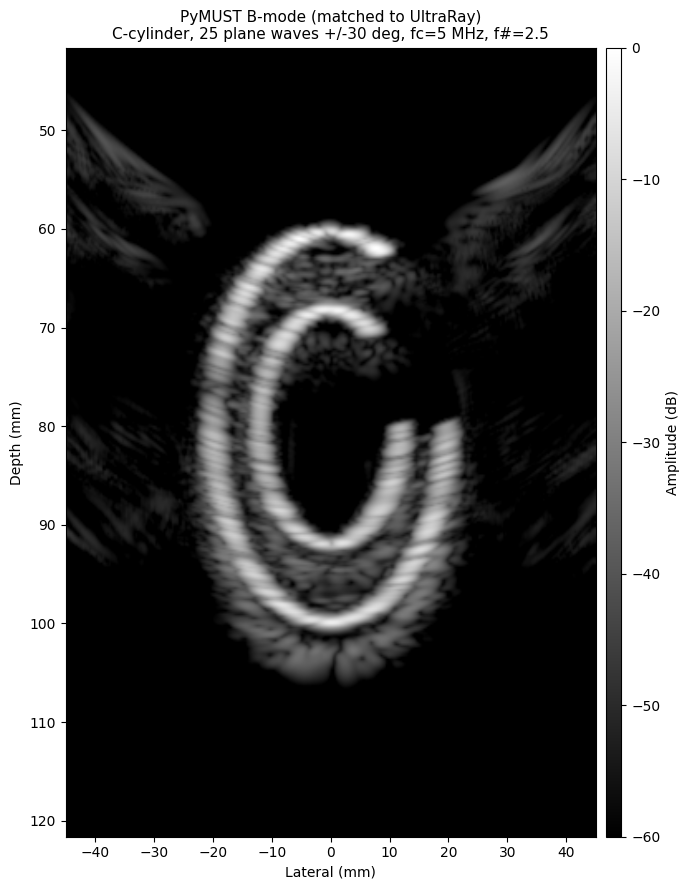

Saved: bmode_pymust_matched.png


In [17]:
env = np.abs(IQ_compounded)
env_smooth = gaussian_filter(env, sigma=0.7)

B = 20 * np.log10(env_smooth / (env_smooth.max() + 1e-12) + 1e-12)
B = np.clip(B, -60, 0)

half_angle = np.radians(70.0 / 2)
angle_px = np.arctan2(X, Z + param.radius)
in_fov = (np.abs(angle_px) <= half_angle) & (Z >= 0.005)
B_display = B.copy()
B_display[~in_fov] = np.nan

fig, ax = plt.subplots(figsize=(7, 9))
fig.patch.set_facecolor('white')
im = ax.imshow(
    B_display,
    extent=[x_range[0]*1e3, x_range[-1]*1e3, z_range[-1]*1e3, z_range[0]*1e3],
    cmap='gray', clim=[-60, 0], aspect='auto', origin='upper', interpolation='bilinear'
)
from mpl_toolkits.axes_grid1 import make_axes_locatable
cb = plt.colorbar(im, cax=make_axes_locatable(ax).append_axes('right', '3%', pad=0.1))
cb.set_label('Amplitude (dB)')
ax.set_title(
    'PyMUST B-mode (matched to UltraRay)\n'
    f'C-cylinder, {Ntx} plane waves +/-30 deg, fc=5 MHz, f#={param.fnumber}',
    fontsize=11
)
ax.set_xlabel('Lateral (mm)'); ax.set_ylabel('Depth (mm)')
ax.set_xlim([-45, 45]); ax.set_ylim([cz_mm + 40, cz_mm - 40])
plt.tight_layout()
plt.savefig('bmode_pymust_matched.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: bmode_pymust_matched.png')


# ------------------------------------------------------------------------
# EXPLANATION
# ------------------------------------------------------------------------
# This cell turns the complex beamformed data into a displayable B-mode and saves it, using the
# same field-of-view as the UltraRay probe so the two images can be laid side by side.
#
# env is the echo envelope (the magnitude of the compound image); a light Gaussian blur (now 0.7
# px, reduced from 1.0 now that the apodization/density/f-number fixes remove most of the clutter
# this used to be papering over) softens residual speckle without blurring the walls. The envelope is
# log-compressed: normalising by its maximum and taking 20*log10 expresses brightness in decibels
# relative to the strongest echo, the small added terms avoid log of zero, and np.clip limits the
# display to a 60 dB window.
#
# The field-of-view mask now uses a half-angle of 35 degrees, which is UltraRay's 70 degree
# opening angle divided by two, and the convex array's 0.03 m curvature radius. angle_px is the
# angular position of each pixel about the virtual apex of the curved array, found from arctan2
# of the lateral coordinate against the depth offset by the curvature radius; pixels outside the
# 35 degree half-angle or shallower than 5 mm lie outside the aperture and are set to NaN so they
# render blank. The plotting block draws the masked image with shallow depths at the top
# (clinical convention), attaches a decibel colour bar, titles the figure with the matched
# acquisition settings, writes a high-resolution PNG and displays it.
